In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pythtb import TBModel, Lattice

## 1. Liste des coordonnées de points (15 pour un sipenki de gen2)

In [39]:
# coords = np.array([
#     [-20.0, 0.0],          # 0
#     [-10.0, 0.0],          # 1
#     [-15.0, 8.660254],     # 2
#     [0.0, 0.0],            # 3
#     [-5.0, 8.660254],      # 4
#     [-10.0, 17.320507],    # 5
#     [10.0, 0.0],           # 6
#     [5.0, 8.660254],       # 7
#     [20.0, 0.0],           # 8
#     [15.0, 8.660254],      # 9
#     [10.0, 17.320507],     # 10
#     [0.0, 17.320507],      # 11
#     [-5.0, 25.98076],      # 12
#     [5.0, 25.98076],       # 13
#     [0.0, 34.641014]       # 14
# ])

df = pd.read_csv("../files/csv/sirpenski_triangle-equi-hetero_points.csv", sep=',', decimal='.')
coords = df[['x', 'y']].to_numpy()

## 2. Liste des connexions entre les points (indices des paires de sites à relier)

In [40]:
# edges = [
#     # Triangle bas-gauche
#     [0, 1], [0, 2], [1, 2],
#     [1, 3], [1, 4], [3, 4],
#     [2, 4], [2, 5], [4, 5],
#     # Triangle bas-droite
#     [3, 6], [3, 7], [6, 7],
#     [6, 8], [6, 9], [8, 9],
#     [7, 9], [7, 10], [9, 10],
#     # Triangle du haut
#     [5, 11], [5, 12], [11, 12],
#     [10, 11], [10, 13], [11, 13],
#     [12, 13], [12, 14], [13, 14]
# ]

df = pd.read_csv("../files/csv/sirpenski_triangle-equi-hetero_edges.csv", sep=',', decimal='.')
edges = df[['i', 'j', 't']].to_numpy()

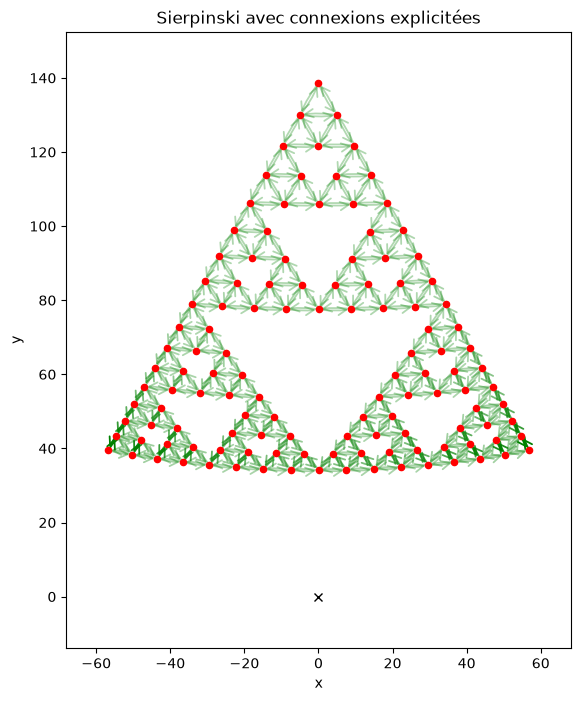

In [43]:

# 3. Création du réseau non-périodique
# np.eye(2) = matrice identité de taille 2 => plan orthonormée
lat = Lattice(np.eye(2), coords, periodic_dirs=[])
model = TBModel(lat)

# 4. Paramètres
# t = -1.0
model.set_onsite([0.0] * len(coords))

# 5. Ajout direct des liaisons depuis le tableau 'edges'
for i, j, t in edges:
    model.set_hop(t, int(i), int(j)) # attention le cast en int ajoute de l'incertitude

# 6. Affichage
model.visualize()
plt.title("Sierpinski avec connexions explicitées")
plt.show()

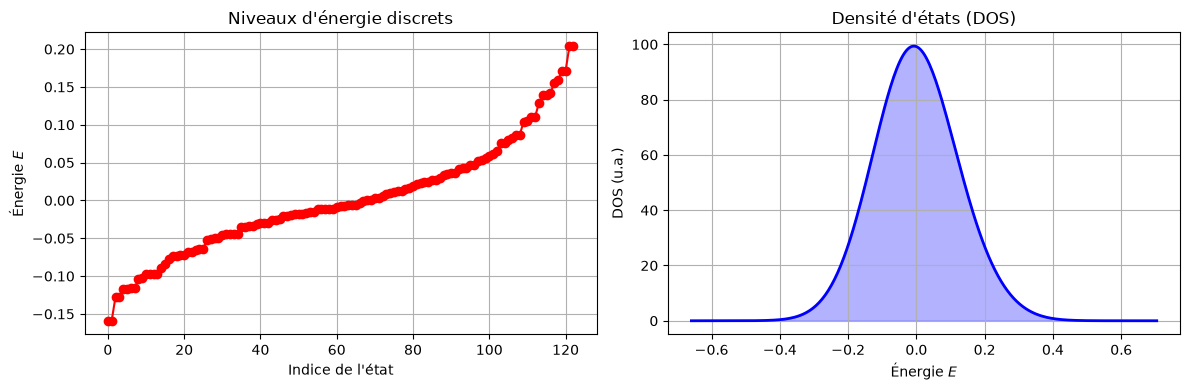

In [44]:
# 1. Calcul des niveaux d'énergie discrets (15 valeurs propres)
evals = model.solve_ham()

# 2. Plot A : Niveaux d'énergie discrets (l'équivalent des "bandes" pour un fractal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graphique des valeurs propres
ax1.plot(evals, 'ro-', markersize=6, linewidth=1.5)
ax1.set_title("Niveaux d'énergie discrets")
ax1.set_xlabel("Indice de l'état")
ax1.set_ylabel("Énergie $E$")
ax1.grid(True)

# 3. Plot B : Densité d'états (DOS) lissée
energies = np.linspace(min(evals) - 0.5, max(evals) + 0.5, 300)
sigma = 0.1  # Élargissement gaussien
dos = np.sum([np.exp(-((energies - e) ** 2) / (2 * sigma ** 2)) for e in evals], axis=0)

ax2.plot(energies, dos, 'b-', linewidth=2)
ax2.fill_between(energies, 0, dos, alpha=0.3, color='b')
ax2.set_title("Densité d'états (DOS)")
ax2.set_xlabel("Énergie $E$")
ax2.set_ylabel("DOS (u.a.)")
ax2.grid(True)

plt.tight_layout()
plt.show()